Loaded: (43405, 70)
Scenario upgrade probabilities:


,Conservative,Base,Aggressive
AAA,0.10,0.10,0.10
AA,0.15,0.15,0.15
A,0.20,0.20,0.25
BBB,0.25,0.35,0.45
BB,0.35,0.50,0.65
B,0.50,0.70,0.80
CCC,0.60,0.80,0.90



Scenario: Conservative
  upgrade=0.0729  none=0.0486  down=0.0361
  Pattern PASS: True
  grade_diff OR=0.9620  p=0.1330
  AUC logit=0.7191  XGB=0.9612  Δ=+0.2422

Scenario: Base
  upgrade=0.0769  none=0.0486  down=0.0270
  Pattern PASS: True
  grade_diff OR=0.9261  p=0.0048
  AUC logit=0.7191  XGB=0.9612  Δ=+0.2421

Scenario: Aggressive
  upgrade=0.0727  none=0.0486  down=0.0230
  Pattern PASS: True
  grade_diff OR=0.9331  p=0.0174
  AUC logit=0.7191  XGB=0.9617  Δ=+0.2426

── Scenario Summary ──


,override_rate,upgrade_rate,dr_upgrade,dr_none,dr_downgrade,pattern_pass,grade_diff_OR,grade_diff_p,grade_diff_sig_10pct,auc_logit,auc_xgb,delta_auc
Scenario,,,,,,,,,,,,
Conservative,0.352,0.1087,0.0729,0.0486,0.0361,True,0.9620,0.1330,False,0.7191,0.9612,0.2422
Base,0.352,0.1444,0.0769,0.0486,0.0270,True,0.9261,0.0048,True,0.7191,0.9612,0.2421
Aggressive,0.352,0.1730,0.0727,0.0486,0.0230,True,0.9331,0.0174,True,0.7191,0.9617,0.2426



── grade_diff Logistic Coefficients ──


,Coefficient,OR,p_value
Scenario,,,
Conservative,-0.0387,0.9620,0.1330
Base,-0.0767,0.9261,0.0048
Aggressive,-0.0692,0.9331,0.0174



── AUC Comparison ──


,AUC_Logit,AUC_XGB,Delta_AUC
Scenario,,,
Conservative,0.7191,0.9612,0.2422
Base,0.7191,0.9612,0.2421
Aggressive,0.7191,0.9617,0.2426



Tables saved.

ROBUSTNESS VERDICT
  PASS  Upgrade DR > None DR (all scenarios)
  FAIL  grade_diff p < 0.10 (all scenarios)
  PASS  grade_diff OR < 1.0 (all scenarios)
  PASS  ΔAUC > 0 (all scenarios)

Overall robustness: PARTIAL – see details above


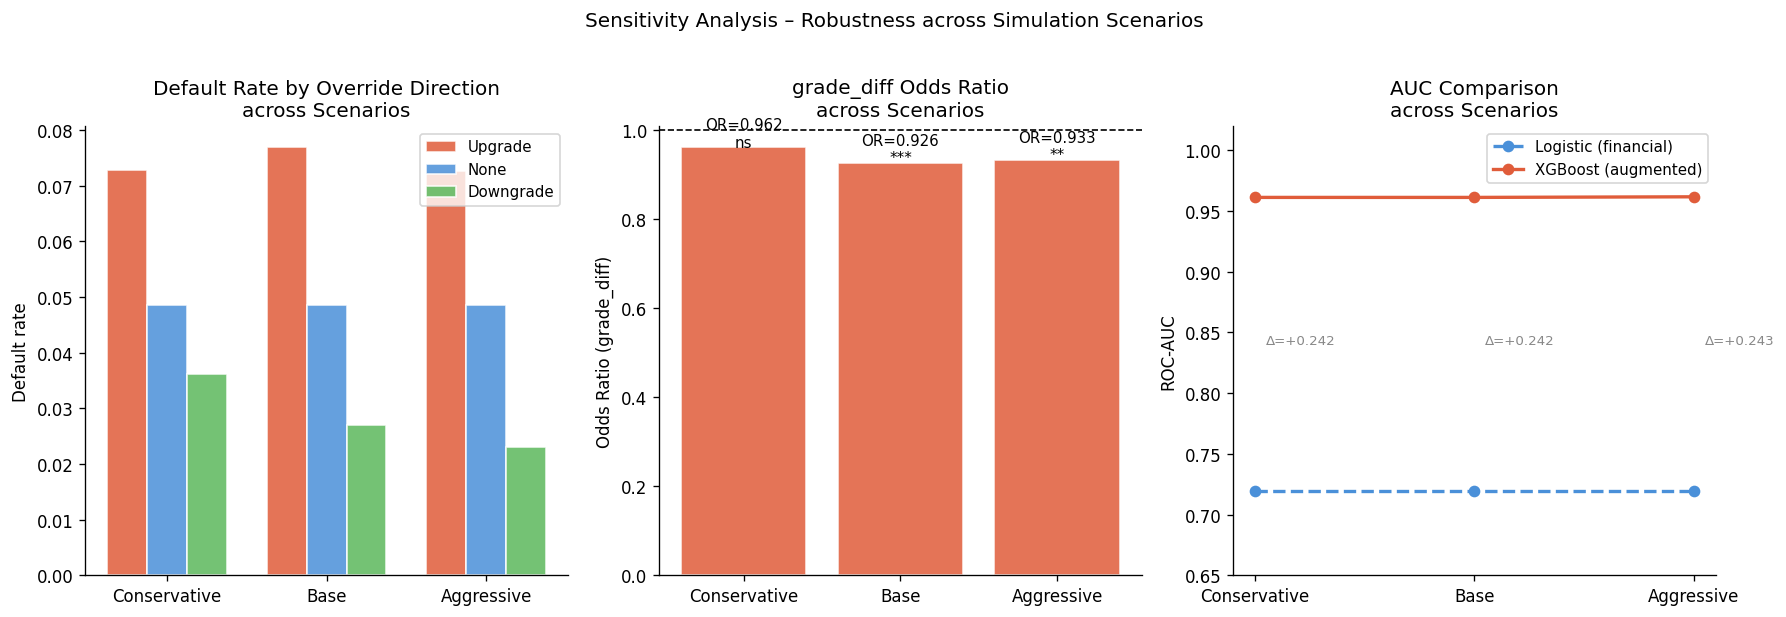

Figure saved: 22_sensitivity_default_rates.png


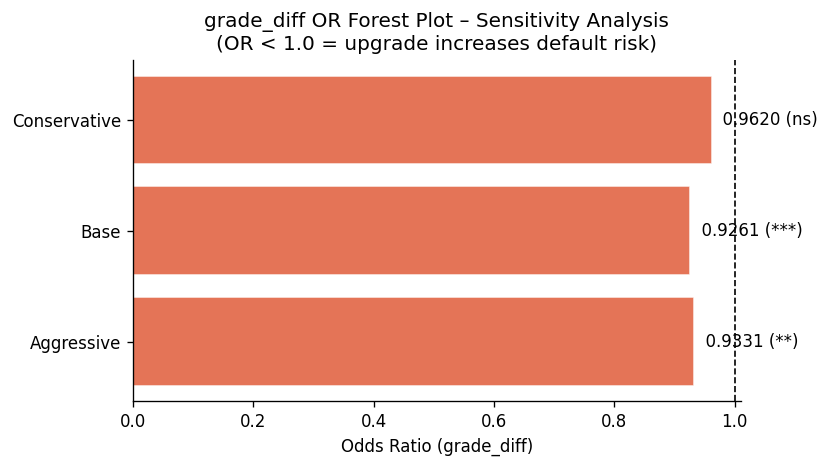

Figure saved: 23_sensitivity_grade_diff_or.png


In [5]:
# NB09_sensitivity_analysis.ipynb

# %% [markdown]
# # NB09 – Sensitivity Analysis (Study B)
# **Purpose:** Verify the robustness of Study A findings by systematically
# varying the simulation parameters (GRADE_UPGRADE_PROB) across three
# scenarios and confirming that core conclusions hold in all cases.
#
# **Research question:**
# Are the key findings sensitive to the choice of simulation parameters,
# or do they hold consistently regardless of the exact upgrade probability
# values assumed?
#
# **Three scenarios:**
#
# | Scenario | CCC | B   | BB  | BBB | Description |
# |----------|-----|-----|-----|-----|-------------|
# | Conservative | 0.60 | 0.50 | 0.35 | 0.25 | Low override pressure |
# | Base (NB04)  | 0.80 | 0.70 | 0.50 | 0.35 | Main analysis |
# | Aggressive   | 0.90 | 0.80 | 0.65 | 0.45 | High override pressure |
#
# **Robustness criteria:**
# 1. upgrade default rate > none default rate (PASS in all 3 scenarios)
# 2. grade_diff OR < 1.0 and p < 0.10 in logistic regression
# 3. XGBoost AUC improvement (ΔAUC > 0) in all 3 scenarios
#
# **Input:**  `data/processed/graded_data.parquet`
# **Output:**
# - `results/tables/15_sensitivity_scenario_summary.csv`
# - `results/tables/16_sensitivity_logit_coefficients.csv`
# - `results/tables/17_sensitivity_auc_comparison.csv`
# - `results/figures/22_sensitivity_default_rates.png`
# - `results/figures/23_sensitivity_grade_diff_or.png`
# - `results/figures/24_sensitivity_auc.png`

# %%
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi"       : 120,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

PROC_DIR  = "../data/processed/"
FIG_DIR   = "../results/figures/"
TABLE_DIR = "../results/tables/"

graded = pd.read_parquet(PROC_DIR + "graded_data.parquet")
print(f"Loaded: {graded.shape}")

GRADE_LABELS = ["AAA", "AA", "A", "BBB", "BB", "B", "CCC"]
GRADE_ORDER  = {g: i for i, g in enumerate(GRADE_LABELS)}
INV_GRADE    = {v: k for k, v in GRADE_ORDER.items()}

# %% [markdown]
# ## 1. Scenario definitions

# %%
SCENARIOS = {
    "Conservative": {
        "AAA": 0.10, "AA": 0.15, "A": 0.20,
        "BBB": 0.25, "BB": 0.35, "B": 0.50, "CCC": 0.60,
    },
    "Base": {
        "AAA": 0.10, "AA": 0.15, "A": 0.20,
        "BBB": 0.35, "BB": 0.50, "B": 0.70, "CCC": 0.80,
    },
    "Aggressive": {
        "AAA": 0.10, "AA": 0.15, "A": 0.25,
        "BBB": 0.45, "BB": 0.65, "B": 0.80, "CCC": 0.90,
    },
}

print("Scenario upgrade probabilities:")
prob_df = pd.DataFrame(SCENARIOS, index=GRADE_LABELS)
display(prob_df)

# %% [markdown]
# ## 2. Simulation function (reused from NB04)

# %%
def simulate_override(df: pd.DataFrame,
                      grade_upgrade_prob: dict,
                      override_rate: float = 0.35,
                      seed: int = 2024) -> pd.DataFrame:
    """Simulate evaluator overrides given grade-based upgrade probabilities."""
    np.random.seed(seed)
    df = df.copy()
    n  = len(df)

    override_mask = np.random.rand(n) < override_rate
    upgrade_prob  = df["system_grade"].map(grade_upgrade_prob).values
    upgrade_flag  = np.random.rand(n) < upgrade_prob
    notch         = np.where(np.random.rand(n) < 0.70, 1, 2)
    delta         = np.where(upgrade_flag, -notch, notch)

    new_ordinal = df["grade_ordinal"].values.copy().astype(int)
    new_ordinal[override_mask] = (
        new_ordinal[override_mask] + delta[override_mask]
    ).clip(0, 6)

    direction = np.full(n, "none", dtype=object)
    direction[override_mask & (delta < 0)] = "upgrade"
    direction[override_mask & (delta > 0)] = "downgrade"

    df["override_flag"]      = override_mask.astype(int)
    df["final_ordinal"]      = new_ordinal
    df["final_grade"]        = [INV_GRADE[o] for o in new_ordinal]
    df["grade_diff"]         = new_ordinal - df["grade_ordinal"].values
    df["override_direction"] = direction
    return df

# %% [markdown]
# ## 3. Feature setup

# %%
FINANCIAL_COLS = [
    "net_profit_to_assets", "total_liabilities_to_assets",
    "working_capital_to_assets", "current_assets_to_short_liabilities",
    "cash_to_current_liabilities", "retained_earnings_to_assets",
    "ebit_to_assets", "book_value_equity_to_liabilities",
    "sales_to_assets", "equity_to_assets",
]
FINANCIAL_COLS = [c for c in FINANCIAL_COLS if c in graded.columns]
ATTR_COLS      = [c for c in graded.columns if c.startswith("Attr")]
OVERRIDE_COLS  = ["pd_system", "grade_ordinal", "grade_diff", "override_flag"]

y = graded["default"]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# %% [markdown]
# ## 4. Run all three scenarios

# %%
scenario_results = []
logit_coef_all  = []
auc_all         = []

for scenario_name, upgrade_probs in SCENARIOS.items():
    print(f"\n{'='*50}")
    print(f"Scenario: {scenario_name}")
    print(f"{'='*50}")

    # 4-1. Simulate override
    df_sim = simulate_override(graded, upgrade_probs, override_rate=0.35)

    # 4-2. Default rate by direction
    dir_stats = (
        df_sim.groupby("override_direction")["default"]
              .agg(n="count", default_rate="mean")
              .reindex(["none", "upgrade", "downgrade"])
              .round(4)
    )
    dr_up   = dir_stats.loc["upgrade",   "default_rate"]
    dr_none = dir_stats.loc["none",       "default_rate"]
    dr_dn   = dir_stats.loc["downgrade",  "default_rate"]

    pass1 = dr_up > dr_none
    pass2 = dr_none > dr_dn
    print(f"  upgrade={dr_up:.4f}  none={dr_none:.4f}  down={dr_dn:.4f}")
    print(f"  Pattern PASS: {pass1 and pass2}")

    # 4-3. Logistic regression (statsmodels)
    ALL_FEAT = FINANCIAL_COLS + [c for c in OVERRIDE_COLS if c in df_sim.columns]
    X_raw    = df_sim[ALL_FEAT].fillna(0)
    scaler   = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_raw),
                            columns=X_raw.columns)
    X_sm     = sm.add_constant(X_scaled)
    logit_m  = sm.Logit(y, X_sm).fit(maxiter=300, disp=False)

    gd_coef = logit_m.params.get("grade_diff", np.nan)
    gd_p    = logit_m.pvalues.get("grade_diff", np.nan)
    gd_or   = np.exp(gd_coef)
    print(f"  grade_diff OR={gd_or:.4f}  p={gd_p:.4f}")

    # 4-4. XGBoost AUC
    FEAT_XGB  = list(dict.fromkeys(FINANCIAL_COLS + ATTR_COLS +
                    [c for c in OVERRIDE_COLS if c in df_sim.columns]))
    X_xgb     = df_sim[FEAT_XGB].fillna(0)
    scale_pos = (y == 0).sum() / (y == 1).sum()

    xgb = XGBClassifier(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=scale_pos,
        eval_metric="logloss", random_state=42,
        n_jobs=-1, verbosity=0,
    )
    p_xgb    = cross_val_predict(xgb, X_xgb, y, cv=cv,
                                  method="predict_proba")[:, 1]
    auc_xgb  = roc_auc_score(y, p_xgb)

    X_fin    = df_sim[FINANCIAL_COLS].fillna(0)
    p_logit  = cross_val_predict(
        LogisticRegression(C=0.1, max_iter=500, class_weight="balanced"),
        X_fin, y, cv=cv, method="predict_proba"
    )[:, 1]
    auc_logit = roc_auc_score(y, p_logit)
    delta_auc = auc_xgb - auc_logit
    print(f"  AUC logit={auc_logit:.4f}  XGB={auc_xgb:.4f}  Δ={delta_auc:+.4f}")

    # Collect results
    scenario_results.append({
        "Scenario"             : scenario_name,
        "override_rate"        : df_sim["override_flag"].mean().round(4),
        "upgrade_rate"         : (df_sim["override_direction"]=="upgrade").mean().round(4),
        "dr_upgrade"           : dr_up,
        "dr_none"              : dr_none,
        "dr_downgrade"         : dr_dn,
        "pattern_pass"         : pass1 and pass2,
        "grade_diff_OR"        : round(gd_or, 4),
        "grade_diff_p"         : round(gd_p, 4),
        "grade_diff_sig_10pct" : gd_p < 0.10,
        "auc_logit"            : round(auc_logit, 4),
        "auc_xgb"              : round(auc_xgb, 4),
        "delta_auc"            : round(delta_auc, 4),
    })

    logit_coef_all.append({
        "Scenario"   : scenario_name,
        "Coefficient": round(gd_coef, 4),
        "OR"         : round(gd_or, 4),
        "p_value"    : round(gd_p, 4),
    })

    auc_all.append({
        "Scenario" : scenario_name,
        "AUC_Logit": round(auc_logit, 4),
        "AUC_XGB"  : round(auc_xgb, 4),
        "Delta_AUC": round(delta_auc, 4),
    })

# %% [markdown]
# ## 5. Summary tables

# %%
summary_df  = pd.DataFrame(scenario_results).set_index("Scenario")
logit_df    = pd.DataFrame(logit_coef_all).set_index("Scenario")
auc_df      = pd.DataFrame(auc_all).set_index("Scenario")

print("\n── Scenario Summary ──")
display(summary_df)

print("\n── grade_diff Logistic Coefficients ──")
display(logit_df)

print("\n── AUC Comparison ──")
display(auc_df)

summary_df.to_csv(TABLE_DIR + "15_sensitivity_scenario_summary.csv")
logit_df.to_csv(TABLE_DIR   + "16_sensitivity_logit_coefficients.csv")
auc_df.to_csv(TABLE_DIR     + "17_sensitivity_auc_comparison.csv")
print("\nTables saved.")

# %% [markdown]
# ## 6. Robustness verdict

# %%
print("\n" + "="*55)
print("ROBUSTNESS VERDICT")
print("="*55)
all_pattern  = summary_df["pattern_pass"].all()
all_sig      = summary_df["grade_diff_sig_10pct"].all()
all_or_lt1   = (summary_df["grade_diff_OR"] < 1.0).all()
all_delta_pos= (summary_df["delta_auc"] > 0).all()

checks = {
    "Upgrade DR > None DR (all scenarios)"  : all_pattern,
    "grade_diff p < 0.10 (all scenarios)"   : all_sig,
    "grade_diff OR < 1.0 (all scenarios)"   : all_or_lt1,
    "ΔAUC > 0 (all scenarios)"              : all_delta_pos,
}
for check, result in checks.items():
    print(f"  {'PASS' if result else 'FAIL'}  {check}")

overall = all(checks.values())
print(f"\nOverall robustness: {'CONFIRMED ✓' if overall else 'PARTIAL – see details above'}")

# %% [markdown]
# ## 7. Visualisations

# %%
scenarios   = list(SCENARIOS.keys())
x           = np.arange(len(scenarios))
width       = 0.25

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot 1: Default rates by direction
for j, (direction, color) in enumerate([
    ("dr_upgrade",   "#E05C3A"),
    ("dr_none",      "#4A90D9"),
    ("dr_downgrade", "#5CB85C"),
]):
    axes[0].bar(x + j*width,
                summary_df[direction].values,
                width, color=color, alpha=0.85,
                edgecolor="white",
                label=direction.replace("dr_", "").capitalize())

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(scenarios)
axes[0].set_ylabel("Default rate")
axes[0].set_title("Default Rate by Override Direction\nacross Scenarios")
axes[0].legend(fontsize=9)

# Plot 2: grade_diff OR across scenarios
axes[1].bar(scenarios, logit_df["OR"].values,
            color=["#E05C3A" if v < 1 else "#4A90D9"
                   for v in logit_df["OR"].values],
            alpha=0.85, edgecolor="white")
axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1)
for i, (or_val, p_val) in enumerate(
        zip(logit_df["OR"], logit_df["p_value"])):
    sig = "***" if p_val < 0.01 else ("**" if p_val < 0.05
          else ("*" if p_val < 0.10 else "ns"))
    axes[1].text(i, or_val + 0.002, f"OR={or_val:.3f}\n{sig}",
                 ha="center", fontsize=9)
axes[1].set_ylabel("Odds Ratio (grade_diff)")
axes[1].set_title("grade_diff Odds Ratio\nacross Scenarios")

# Plot 3: AUC comparison
axes[2].plot(scenarios, auc_df["AUC_Logit"].values,
             "o--", color="#4A90D9", linewidth=2, label="Logistic (financial)")
axes[2].plot(scenarios, auc_df["AUC_XGB"].values,
             "o-",  color="#E05C3A", linewidth=2, label="XGBoost (augmented)")
for i, (al, ax_val) in enumerate(
        zip(auc_df["AUC_Logit"], auc_df["AUC_XGB"])):
    axes[2].annotate(f"Δ={ax_val-al:+.3f}",
                     xy=(i, (al+ax_val)/2),
                     xytext=(i+0.05, (al+ax_val)/2),
                     fontsize=8, color="#888")
axes[2].set_ylabel("ROC-AUC")
axes[2].set_title("AUC Comparison\nacross Scenarios")
axes[2].legend(fontsize=9)
axes[2].set_ylim(0.65, 1.02)

plt.suptitle("Sensitivity Analysis – Robustness across Simulation Scenarios",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR + "22_sensitivity_default_rates.png", bbox_inches="tight")
plt.show()
print("Figure saved: 22_sensitivity_default_rates.png")

# %% [markdown]
# ## 8. grade_diff OR forest plot

# %%
fig, ax = plt.subplots(figsize=(7, 4))
colors_or = ["#E05C3A" if v < 1 else "#4A90D9"
             for v in logit_df["OR"].values]
ax.barh(scenarios[::-1], logit_df["OR"].values[::-1],
        color=colors_or[::-1], alpha=0.85, edgecolor="white")
ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
for i, (or_v, p_v) in enumerate(
        zip(logit_df["OR"].values[::-1],
            logit_df["p_value"].values[::-1])):
    sig = "***" if p_v<0.01 else ("**" if p_v<0.05
          else ("*" if p_v<0.10 else "ns"))
    ax.text(or_v + 0.001, i, f"  {or_v:.4f} ({sig})",
            va="center", fontsize=10)
ax.set_xlabel("Odds Ratio (grade_diff)")
ax.set_title("grade_diff OR Forest Plot – Sensitivity Analysis\n"
             "(OR < 1.0 = upgrade increases default risk)")
plt.tight_layout()
plt.savefig(FIG_DIR + "23_sensitivity_grade_diff_or.png", bbox_inches="tight")
plt.show()
print("Figure saved: 23_sensitivity_grade_diff_or.png")